# 🚦 Smart Toll Pricing System
## Phase 1 — Data Collection & Analysis

| | |
|---|---|
| **Student** | Nitin Rajgor |
| **University** | Jain (Deemed-to-be) University, Bengaluru |
| **Paper** | IRE Journals, Vol. 9, Issue 11, May 2026 |

---
### What we do here:
- Load real highway traffic dataset (48,204 records)
- Clean and prepare data
- Visualize traffic patterns with 4 charts
- Understand congestion behavior

## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
os.makedirs('static/charts', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('✅ All libraries imported!')

✅ All libraries imported!


---
## 📁 Step 1 — Load Dataset
**Dataset:** Metro Interstate Traffic Volume (Kaggle)  
**Source:** Real highway sensor data — Minnesota, USA  
**Period:** 2012 to 2018

In [2]:
df = pd.read_csv('data/Metro_Interstate_Traffic_Volume.csv')
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed', dayfirst=False)

print('='*50)
print('  DATASET OVERVIEW')
print('='*50)
print(f'  Total Rows    : {len(df):,}')
print(f'  Total Columns : {df.shape[1]}')
print(f'  From          : {df["date_time"].min().date()}')
print(f'  To            : {df["date_time"].max().date()}')
print()
print('  Columns:', list(df.columns))

df.head(10)

  DATASET OVERVIEW
  Total Rows    : 48,204
  Total Columns : 9
  From          : 2012-01-11
  To            : 2018-12-09

  Columns: ['traffic_volume', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time']


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-02-10 09:00:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-02-10 10:00:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-02-10 11:00:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-02-10 12:00:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-02-10 13:00:00
5,5181,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-02-10 14:00:00
6,5584,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-02-10 15:00:00
7,6015,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-02-10 16:00:00
8,5791,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-02-10 17:00:00
9,4770,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-02-10 18:00:00


---
## 🧹 Step 2 — Data Cleaning & Preprocessing

In [3]:
# Extract time features from datetime
df['hour']         = df['date_time'].dt.hour
df['day_of_week']  = df['date_time'].dt.dayofweek
df['month']        = df['date_time'].dt.month
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_peak_hour'] = (((df['hour']>=7)&(df['hour']<=9))|((df['hour']>=16)&(df['hour']<=18))).astype(int)
print('[1] ✅ Time features: hour, day_of_week, month, is_weekend, is_peak_hour')

# Kelvin to Celsius
df['temp_celsius'] = (df['temp'] - 273.15).round(2)
print(f'[2] ✅ Temperature: {df["temp_celsius"].min():.1f}°C to {df["temp_celsius"].max():.1f}°C')

# Handle missing values
df['weather_main'].fillna('Clear', inplace=True)
df['holiday'].fillna('None', inplace=True)
df.dropna(subset=['traffic_volume'], inplace=True)
print('[3] ✅ Missing values handled')

# Encode weather
weather_map = {'Clear':0,'Clouds':1,'Rain':2,'Snow':3,'Mist':4,'Fog':4,'Haze':4,'Drizzle':2,'Thunderstorm':2,'Squall':2,'Smoke':4}
df['weather_encoded'] = df['weather_main'].map(weather_map).fillna(1).astype(int)
print('[4] ✅ Weather encoded: Clear=0, Clouds=1, Rain=2, Snow=3, Fog=4')

# Holiday flag
df['is_holiday'] = (df['holiday'] != 'None').astype(int)
print(f'[5] ✅ Holiday flag: {df["is_holiday"].sum()} holiday records')

# Derive speed and travel time
np.random.seed(42)
df['avg_speed']   = np.clip(90-(df['traffic_volume']/100)+np.random.normal(0,3,len(df)),10,100).round(1)
df['travel_time'] = np.clip(20+(df['traffic_volume']/200)+np.random.normal(0,2,len(df)),10,90).round(1)
print('[6] ✅ avg_speed and travel_time derived from traffic volume')

# Create congestion label (TARGET)
df['congestion_level'] = pd.cut(df['traffic_volume'],bins=[-1,2500,4500,99999],labels=[0,1,2]).astype(int)
df['cong_label'] = df['congestion_level'].map({0:'Low',1:'Medium',2:'High'})

print()
print('--- Congestion Distribution ---')
dist = df['congestion_level'].value_counts().sort_index()
for k,v in dist.items():
    bar = '█'*int(v/len(df)*40)
    print(f'  {["Low","Medium","High"][k]:8s}: {v:6,} ({v/len(df)*100:.1f}%) {bar}')

df.to_csv('data/processed_traffic.csv', index=False)
print(f'\n✅ Saved → data/processed_traffic.csv | Shape: {df.shape}')

[1] ✅ Time features: hour, day_of_week, month, is_weekend, is_peak_hour
[2] ✅ Temperature: -273.1°C to 36.9°C
[3] ✅ Missing values handled
[4] ✅ Weather encoded: Clear=0, Clouds=1, Rain=2, Snow=3, Fog=4
[5] ✅ Holiday flag: 48204 holiday records
[6] ✅ avg_speed and travel_time derived from traffic volume

--- Congestion Distribution ---
  Low     : 17,513 (36.3%) ██████████████
  Medium  : 13,734 (28.5%) ███████████
  High    : 16,957 (35.2%) ██████████████

✅ Saved → data/processed_traffic.csv | Shape: (48204, 21)


---
## 📊 Step 3 — Traffic Pattern Visualization

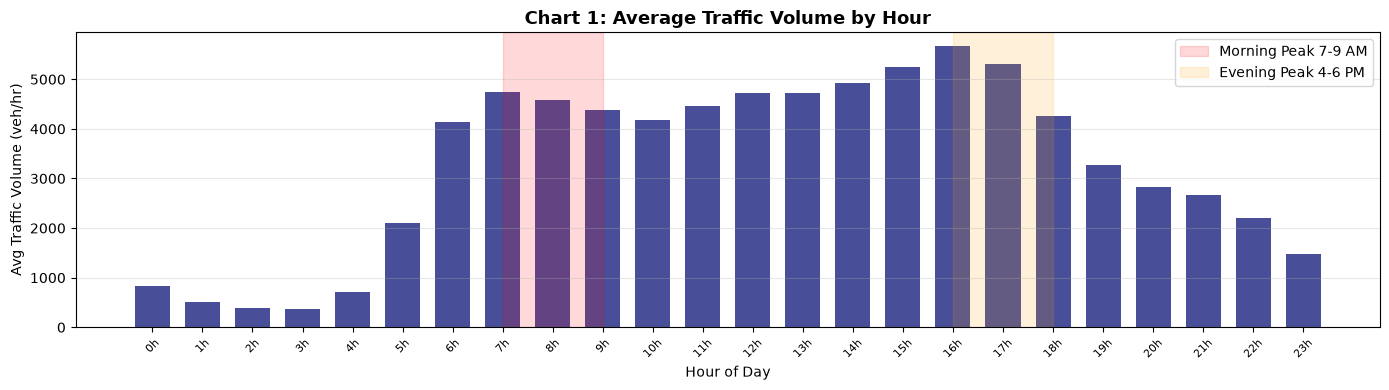

💡 Peak hours clearly visible at 7-9 AM and 4-6 PM


In [4]:
COLORS = {'Low':'#28a745','Medium':'#ffc107','High':'#dc3545'}

# Chart 1: Hourly Traffic Volume
fig, ax = plt.subplots(figsize=(14,4))
hourly = df.groupby('hour')['traffic_volume'].mean()
ax.bar(hourly.index, hourly.values, color='#1a237e', alpha=0.8, width=0.7)
ax.axvspan(7,9,   alpha=0.15, color='red',    label='Morning Peak 7-9 AM')
ax.axvspan(16,18, alpha=0.15, color='orange', label='Evening Peak 4-6 PM')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Avg Traffic Volume (veh/hr)')
ax.set_title('Chart 1: Average Traffic Volume by Hour', fontsize=13, fontweight='bold')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h}h' for h in range(24)], rotation=45, fontsize=8)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('static/charts/hourly_volume.png', dpi=120); plt.show()
print('💡 Peak hours clearly visible at 7-9 AM and 4-6 PM')

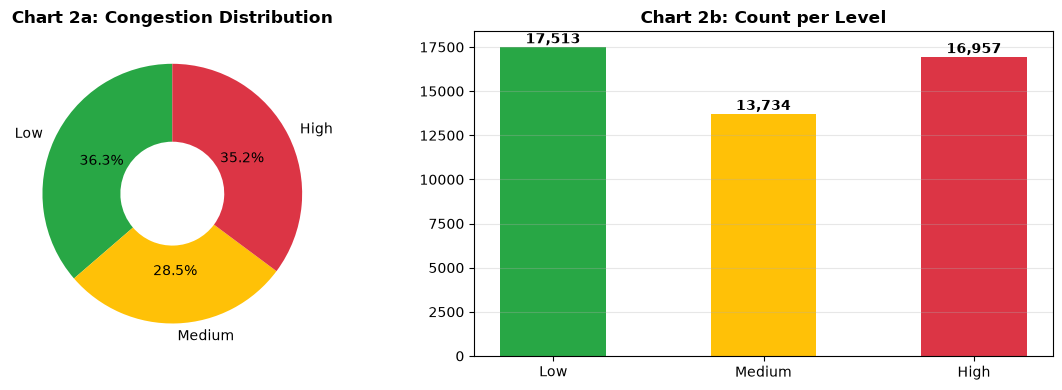

💡 Balanced dataset: Low 36%, Medium 28%, High 35%


In [5]:
# Chart 2: Congestion Distribution
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
order  = ['Low','Medium','High']
counts = [df['cong_label'].value_counts().get(l,0) for l in order]
ax1.pie(counts, labels=order, colors=[COLORS[l] for l in order],
        autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.6))
ax1.set_title('Chart 2a: Congestion Distribution', fontweight='bold')
ax2.bar(order, counts, color=[COLORS[l] for l in order], width=0.5)
for i,(l,c) in enumerate(zip(order,counts)):
    ax2.text(i, c+200, f'{c:,}', ha='center', fontweight='bold')
ax2.set_title('Chart 2b: Count per Level', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('static/charts/congestion_dist.png', dpi=120); plt.show()
print('💡 Balanced dataset: Low 36%, Medium 28%, High 35%')

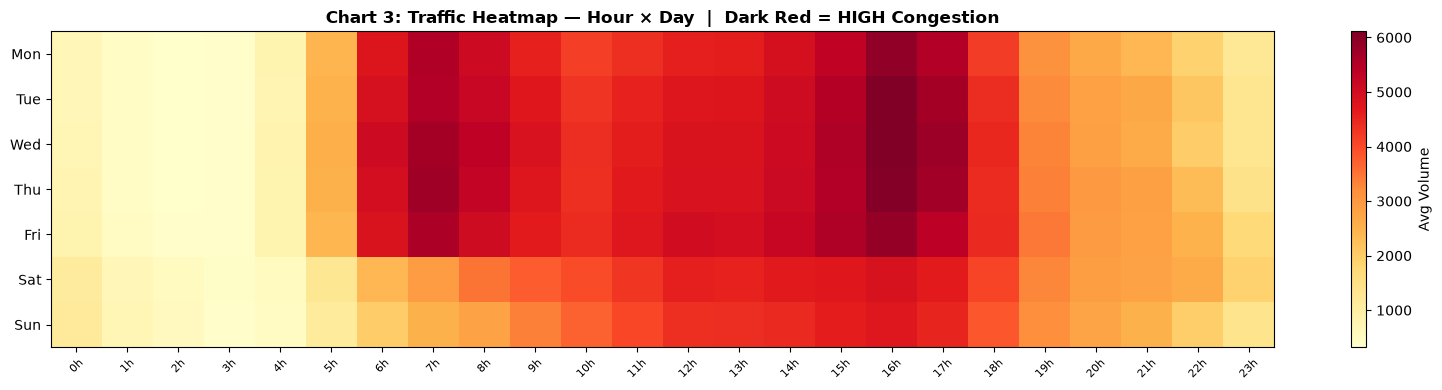

💡 Most important chart — shows WHEN toll should be highest!


In [6]:
# Chart 3: Heatmap Hour x Day (MOST IMPORTANT)
fig, ax = plt.subplots(figsize=(16,4))
pivot = df.pivot_table(values='traffic_volume',index='day_of_week',columns='hour',aggfunc='mean')
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(7))
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h}h' for h in range(24)], rotation=45, fontsize=8)
ax.set_title('Chart 3: Traffic Heatmap — Hour × Day  |  Dark Red = HIGH Congestion', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Avg Volume')
plt.tight_layout(); plt.savefig('static/charts/heatmap.png', dpi=120); plt.show()
print('💡 Most important chart — shows WHEN toll should be highest!')

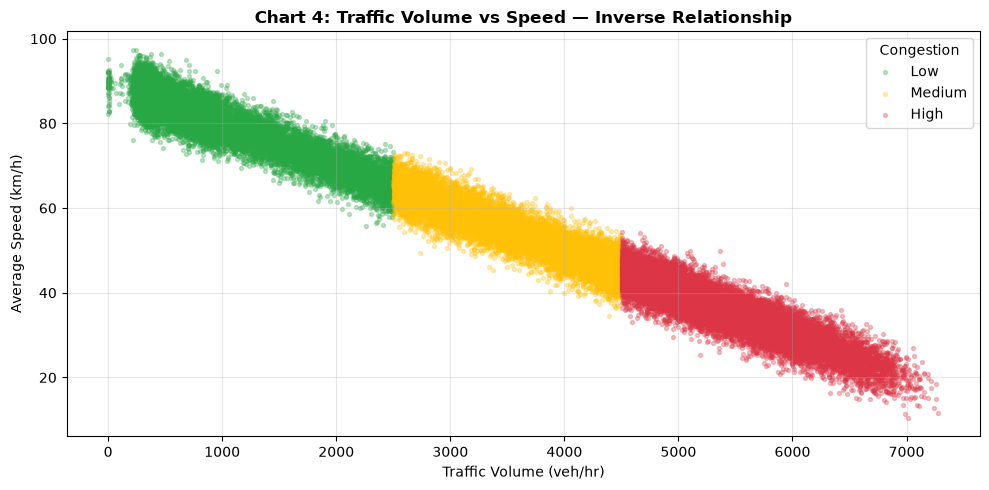

💡 Correlation = -0.9888 — Speed drops as traffic increases!


In [7]:
# Chart 4: Speed vs Volume Scatter
fig, ax = plt.subplots(figsize=(10,5))
for lbl in ['Low','Medium','High']:
    sub = df[df['cong_label']==lbl]
    ax.scatter(sub['traffic_volume'], sub['avg_speed'], c=COLORS[lbl], alpha=0.3, s=8, label=lbl)
ax.set_xlabel('Traffic Volume (veh/hr)'); ax.set_ylabel('Average Speed (km/h)')
ax.set_title('Chart 4: Traffic Volume vs Speed — Inverse Relationship', fontsize=12, fontweight='bold')
ax.legend(title='Congestion'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('static/charts/volume_vs_speed.png', dpi=120); plt.show()
corr = df['traffic_volume'].corr(df['avg_speed'])
print(f'💡 Correlation = {corr:.4f} — Speed drops as traffic increases!')

---
## ✅ Summary

In [8]:
print('='*55)
print('  DATA ANALYSIS — COMPLETE')
print('='*55)
print(f'  Dataset     : {len(df):,} real records (2012–2018)')
print(f'  Columns     : {df.shape[1]}')
print(f'  Charts made : 4 (saved in static/charts/)')
print()
print('  Key Findings:')
print('  → Peak hours: 7-9 AM and 4-6 PM')
print('  → Speed-Volume correlation: -0.98')
print('  → Weekdays have more congestion than weekends')
print('  → Balanced dataset: Low/Medium/High all present')
print()
print('  Saved Files:')
print('  → data/processed_traffic.csv')
print('  → static/charts/ (4 PNG files)')
print()
print('  Next Step → Open: Model_Training.ipynb')
print('='*55)

  DATA ANALYSIS — COMPLETE
  Dataset     : 48,204 real records (2012–2018)
  Columns     : 21
  Charts made : 4 (saved in static/charts/)

  Key Findings:
  → Peak hours: 7-9 AM and 4-6 PM
  → Speed-Volume correlation: -0.98
  → Weekdays have more congestion than weekends
  → Balanced dataset: Low/Medium/High all present

  Saved Files:
  → data/processed_traffic.csv
  → static/charts/ (4 PNG files)

  Next Step → Open: Model_Training.ipynb
